## Lecture 4: Parallel Computing 1 — Peer Review MP1, Amdahl's Law & Multiprocessing

### ****Exercises 1:** MC π Serial**

**Write and time `estimate_pi_serial()`**

****Write** `estimate_pi_serial(num_samples)` — **a plain Python loop:****

**1. Draw two uniform random numbers $x, y ∈ [0, 1)$**

**2. Count a *hit* when $x^2 + y^2 \le 1$**

**3. Return 4 × hits/num samples**

****Time it:** use `time.perf counter()` with 3 runs, take `statistics.median()`. Try `num_samples = 10_000_000`.**

In [1]:
# From slide 38, modified by me to use main function


import math, random, time, statistics
random.seed(0) # Deterministic results (regarding points) I have added this

def estimate_pi_serial(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return 4 * inside_circle / num_samples


def main():
    num_samples = 10_000_000
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
    t_serial = statistics.median(times)
    print(f"pi estimate: {pi_estimate:.6f} (error: {abs(pi_estimate-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")


if __name__ == '__main__':
    main()

pi estimate: 3.141658 (error: 0.000065)
Serial time: 1.002s


**Questions:**

- **How accurate is the estimate? Run several times — does it vary?**

In [2]:
for i in range(5):
    main()

pi estimate: 3.141837 (error: 0.000244)
Serial time: 0.922s
pi estimate: 3.141890 (error: 0.000297)
Serial time: 0.972s
pi estimate: 3.142002 (error: 0.000409)
Serial time: 0.937s
pi estimate: 3.141593 (error: 0.000000)
Serial time: 0.934s
pi estimate: 3.142273 (error: 0.000680)
Serial time: 0.940s


Worst accuracy was about $\frac{1}{1000}$. We can see that the runtime does vary. This is expected since the points are randomly positioned. 

- **What is the serial time? This will be your speedup denominator in E3.**

It was $T_1 = 1.002$ s.

****Done?** Note your serial time → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 403837fbd30986107ca8c81c930cc4d4771e19c1 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Thu Mar 5 20:06:40 2026 +0000

    l04: exercise 1 done
```

### ****Exercises 2:** MC π Parallel**

**Parallelize with `Pool.map(); sweep 1. . . cpu count()` workers**

****Parallelize using `Pool.map` — each worker returns a hit count (an integer):****
- **Worker function `estimate_pi_chunk(num samples)`: runs the loop, returns `inside_circle`**
- **Main process: sum worker results, divide by total samples to get $\hat{\pi}$**
- **Why good IPC? Input: one integer per task. Output: one integer per task. No arrays.**

****Sweep** `num_processes` from 1 to `os.cpu count()`. For each worker count: measure elapsed time and compute speedup.**

In [3]:
# From slide 40

from multiprocessing import Pool
import os
import random
import time
import statistics


def estimate_pi_chunk(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x, y = random.random(), random.random()
        if x*x + y*y <= 1:
            inside_circle += 1
    return inside_circle


def estimate_pi_parallel(num_samples, num_processes=4):
    samples_per_process = num_samples // num_processes
    tasks = [samples_per_process] * num_processes
    with Pool(processes=num_processes) as pool:
        results = pool.map(estimate_pi_chunk, tasks)
    return 4 * sum(results) / num_samples


if __name__ == '__main__':
    num_samples = 10_000_000
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            times.append(time.perf_counter() - t0)
        t = statistics.median(times)
        print(f"{num_proc:2d} workers: {t:.3f}s pi={pi_est:.6f}")

 1 workers: 0.850s pi=3.142342
 2 workers: 0.468s pi=3.141451
 3 workers: 0.346s pi=3.141202
 4 workers: 0.282s pi=3.141625
 5 workers: 0.249s pi=3.141779
 6 workers: 0.252s pi=3.141360
 7 workers: 0.216s pi=3.141729
 8 workers: 0.234s pi=3.142135
 9 workers: 0.252s pi=3.141429
10 workers: 0.221s pi=3.140626
11 workers: 0.226s pi=3.142318
12 workers: 0.226s pi=3.141220
13 workers: 0.230s pi=3.141670
14 workers: 0.242s pi=3.141672
15 workers: 0.228s pi=3.141798
16 workers: 0.231s pi=3.140734


**Questions:**

- **Do all worker counts give the same $\hat{\pi}$? Why or why not?**

No, they do not. This is expected since the points are randomly positioned. This results in some *workers* having more or less points lay inside, which can be seen as the *noise* in the value of pie.

- **At which count do you first see a meaningful speedup?**

From 1 worker to 2 workers, resulting in a speedup of $S = \frac{T_1}{T_2} = \frac{0.850 \text{s}}{0.468 \text{s}} = 1.82\times$.

****Done?** Check $\hat{\pi}$ is consistent across runs → continue to E3**

Noted! It appears that $\hat{\pi}$ is stable.

### ****Exercises 3:** MC π Analysis**

**Speedup curve; efficiency table; back-solve implied serial fraction**

****Parallel efficiency:** $E_p = \frac{S_p}{p}$ — fraction of ideal speedup per core (100% = perfect). **For each worker count (1 to `cpu count()`), tabulate:** workers | time ($s$) | speedup $S_p$ | efficiency $E_p$(%)**

****Questions to discuss:****

**1. At which worker count $p^∗$ is speedup maximum?**

First of all, lets compute the results and save them.

In [4]:
import numpy as np
from pathlib import Path

def compute_results():
    results = [] 
    num_samples = 10_000_000
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            times.append(time.perf_counter() - t0)
        t = statistics.median(times)
        print(f"{num_proc:2d} workers: {t:.3f}s pi={pi_est:.6f}")
        results.append(t)
    return results


# Persist the results
results_file = Path("l04_results.npy")
if not results_file.exists():
    res = compute_results()
    np.save(results_file, res)

 1 workers: 0.895s pi=3.142018
 2 workers: 0.472s pi=3.141336
 3 workers: 0.343s pi=3.141011
 4 workers: 0.283s pi=3.140884
 5 workers: 0.247s pi=3.141234
 6 workers: 0.229s pi=3.141175
 7 workers: 0.216s pi=3.141007
 8 workers: 0.206s pi=3.141309
 9 workers: 0.243s pi=3.141387
10 workers: 0.240s pi=3.140991
11 workers: 0.241s pi=3.141343
12 workers: 0.260s pi=3.142051
13 workers: 0.265s pi=3.141754
14 workers: 0.264s pi=3.141576
15 workers: 0.263s pi=3.141297
16 workers: 0.266s pi=3.141016


In [5]:
results = np.load(results_file)

speedups = [results[0] / time_parallel for time_parallel in results]
s_max = max(speedups)
p_star = speedups.index(s_max) + 1

print(f"Maximum speedup of {s_max:.2f}x achieved using {p_star} workers")

Maximum speedup of 4.34x achieved using 8 workers


**2. Does speedup plateau or drop beyond $p^∗$? Why?**

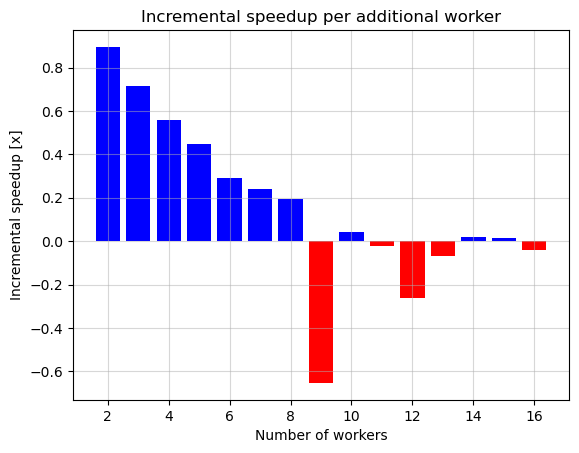

In [6]:
import numpy as np
import matplotlib.pyplot as plt

diff = np.diff(np.array(speedups))
workers = range(2, len(speedups)+1)

# AI assisted colours
colors = []
for d in diff:
    if d > 1: # Superlinear
        colors.append("green")
    elif d > 0: # Normal
        colors.append("blue")
    else: # d < 1 slowdown bad
        colors.append("red")

plt.bar(workers, diff, color=colors)
plt.title("Incremental speedup per additional worker")
plt.ylabel("Incremental speedup [x]")
plt.xlabel("Number of workers")
plt.grid(alpha=0.5)
plt.show()

The plot above shows the difference between the speedup of going form $n$ workers to $n+1$ workers. Expected range is $[0-1]$, $<1$ is a regression or *slowdown, and $>1$ is a superlinear speedup.

From the plot, we can see that the speedup plateaus for more than 8 workers.

**3. **Back-solve implied serial fraction:** $s = \frac{1/S_{p^*} - 1/p^*}{1 - 1/p^*}$ — what fraction of time is effectively serial (IPC overhead + spawning)?**

In [7]:
s =  (1/s_max - 1/p_star) / (1 - 1/p_star)

print(f"Back-solved: Approximately {s*100:.2f}% is serial.")

Back-solved: Approximately 12.05% is serial.


**4. **Mac M1/M2/M3 users:** do you see a slope change near worker 8 (E-cores)?**

I do own a Mac with any of these processors.

****(Optional) Plot:** workers (x) vs. speedup (y) — actual and ideal linear.**

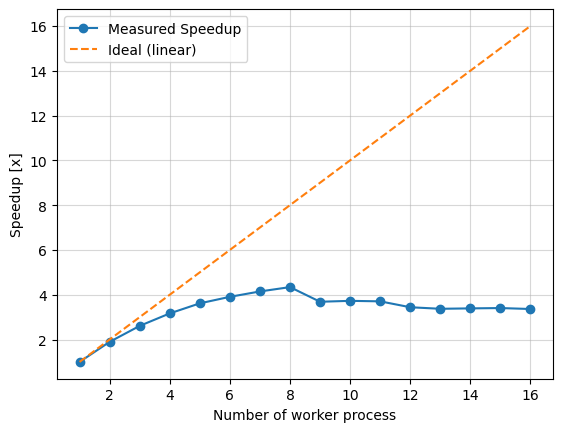

In [8]:
workers = range(1, len(speedups)+1)
ideal = range(1, len(speedups)+1)

plt.plot(workers, speedups, marker="o", label="Measured Speedup")
plt.plot(ideal, ideal, linestyle="--", label="Ideal (linear)")
plt.ylabel("Speedup [x]")
plt.xlabel("Number of worker process")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

****Done?** Discuss with a neighbour → move on to MP2 milestones**

We can see that Simultaneous Multi-Threading SMT (AMD's version of Intel HypeThreading) does not help in terms of speedup. In fact, it seems to result in a slowdown compared to using just the physical number of cores.

*CPU* 8 core, 16 threads

### ****Milestone 1:** Parallel Mandelbrot**

**Refactor to chunk-based Numba kernels**

In [9]:
# From slide 45 (The updated once)

# mandelbrot_parallel.py (Tasks 1-3 are one continuous script)
import numpy as np
from numba import njit
from multiprocessing import Pool
import time, os, statistics, matplotlib.pyplot as plt
from pathlib import Path

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N,
                     x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter=100):
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

**Refactor your MP1 Numba code into three functions (two `@njit`, one plain wrapper):**

**`mandelbrot_pixel(c_real, c_imag, max_iter)` The scalar kernel you already have from L03. Returns the escape iteration count for a single complex point.**

**`mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter)` Loops over rows [row start, row end) and all columns. Computes pixel coordinates from index + bounds — no arrays received as input. Returns a (row end - row start)×N int32 array.**

**`mandelbrot_serial(N, x_min, ...) Thin wrapper: calls mandelbrot_chunk(0, N, ...)` — the whole grid as one chunk.**

I am a bit unsure as to what exact *L03 output* is. I assume that it is the numba compiled version.

In [10]:
from numba import njit
import numpy as np
# Copied from lecture 3

@njit                       # <-- entire function compiled !
def mandelbrot_naive_numba(xmin, xmax, ymin, ymax, width, height, max_iter=100):
    """Fully JIT - compiled Mandelbrot --- structure identical to naive."""
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    result = np.zeros((height, width), dtype=np.int32)

    for i in range(height):             # compiled loop
        for j in range(width):          # compiled loop
            c = x[j] + 1j * y[i]
            z = 0j                      # complex literal: type inference works!
            n = 0
            while n < max_iter and (z.real*z.real + z.imag*z.imag) <= 4.0:
                z = z*z + c
                n += 1
            result[i, j] = n
    return result

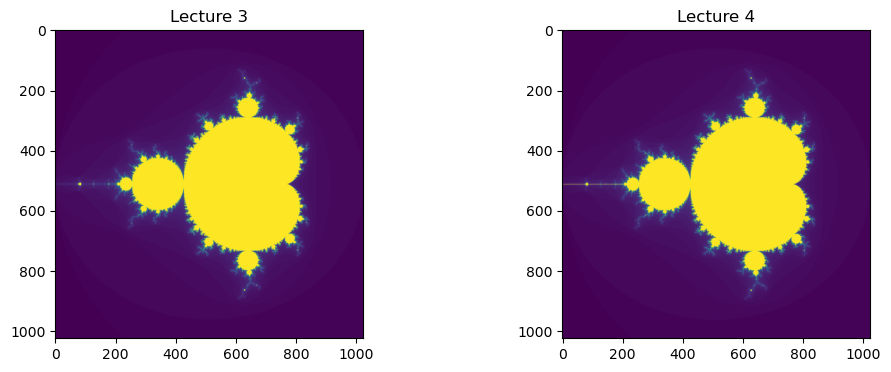

In [11]:
mandelbrot_naive_numba(-2, 1, -1.5, 1.5, 1024, 1024, 100)
l03_image = mandelbrot_naive_numba(-2, 1, -1.5, 1.5, 1024, 1024, 100)
l04_image = mandelbrot_serial(1024, -2, 1, -1.5, 1.5, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(l03_image)
axes[0].set_title("Lecture 3")
axes[1].imshow(l04_image)
axes[1].set_title("Lecture 4")
plt.show()

They look the same.

****Done?** Serial result matches your L03 output → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 462cfa1b608b71de84442488d75ecdb95192a29e (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Mar 6 13:21:19 2026 +0000

    l04: milestone 1 done
```

### ****Milestone 2:** Parallel Mandelbrot**

**Implement Pool.map wrapper; verify result**

In [12]:
# From slide 47

# --- MP2 M2: add below M1 in mandelbrot_parallel.py ---
def _worker(args):
    return mandelbrot_chunk(*args)

def mandelbrot_parallel(N, x_min, x_max, y_min, y_max,
                        max_iter=100, n_workers=4):
    chunk_size = max(1, N // n_workers)
    chunks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        chunks.append((row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end

    with Pool(processes=n_workers) as pool:
        pool.map(_worker, chunks)       # un-timed warm-up: Numba JIT in workers
        parts = pool.map(_worker, chunks)
    return np.vstack(parts)

if __name__ == '__main__':
    result = mandelbrot_parallel(1024, -2.5, 1.0, -1.25, 1.25, n_workers=4)

- ****Write** `mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers)`**
    - **Build a list of chunk tuples: (rows_tart, row_end, N, x_min, x_max, y_min, y_max, max_iter)**
    - **Use `pool.map(_worker, chunks)` to distribute across workers**
    - **Reassemble with `np.vstack(parts)`**

- ****Pass only parameters — not a pre-computed grid****
    - **In MP1 we pre-created the full complex grid `C` and passed it to the iteration algorithm — passing a slice of that array to each worker would mean sending ∼8 KB per task over IPC**
    - **Instead: pass only scalar bounds `(x_min, x_max, y_min, y_max, N)` and let each worker compute its own coordinates**
    - **IPC input per task: ∼60 bytes (8 scalars) vs. ∼8 KB (1024-element float64 array)**
    - **IPC output per task is unavoidable: chunk size × N × 4 bytes (the result array)**

- ****Wrapper function** `_worker(args)`**
    - **`pool.map` calls `func(item)` — it takes only one argument**
    - **`mandelbrot_chunk` takes 8 arguments, so `_worker` receives the packed tuple and unpacks it**
    - **Normally, this can be done with a lambda function, but lambdas are not picklable, so it must be defined as function at module level.**

****Done?** Verify result matches serial → commit**

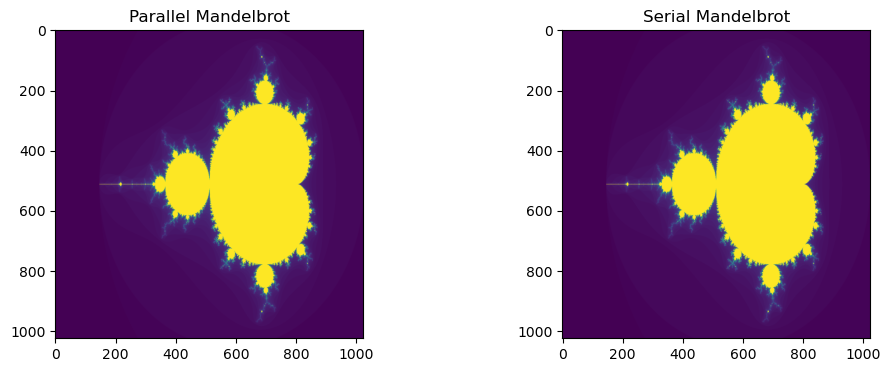

In [13]:
result_serial = mandelbrot_serial(1024, -2.5, 1.0, -1.25, 1.25)
# Note that the x_min has changed in the slides.
# That is why the imamge looks a bit squeezed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(result)
axes[0].set_title("Parallel Mandelbrot")
axes[1].imshow(result_serial)
axes[1].set_title("Serial Mandelbrot")
plt.show()

They look the same. We are all good.

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 26184378749da1d2f87a7f3806dc9a3e64851ce4 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Mar 6 13:40:19 2026 +0000

    l04: milestone 2 done
```

### ****Milestone 3:** Parallel Mandelbrot**

**Benchmark sweep; speedup and efficiency table**

****Serial baseline:** call mandelbrot serial 3 times after your M1 warm-up (Numba already compiled in main process); take median**

- **Where to place the timer:**
    - **Start `t0` immediately before `pool.map()`**
    - **Stop immediately after `np.vstack(parts)` — include assembly time**
    - **Keep Pool creation *outside* the timed region**

In [13]:
# From slide 49

# --- MP2 M3: benchmark (in __main__ block) ---
N, max_iter = 1024, 100
X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25

# Serial baseline (Numba already warm after M1 warm-up)
times = []
for _ in range(3):
    t0 = time.perf_counter()
    mandelbrot_serial(N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter)
    times.append(time.perf_counter() - t0)
t_serial = statistics.median(times)

for n_workers in range(1, os.cpu_count() + 1):
    chunk_size = max(1, N // n_workers)
    chunks, row = [], 0
    while row < N:
        end = min(row + chunk_size, N)
        chunks.append((row, end, N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter))
        row = end
    with Pool(processes=n_workers) as pool:
        pool.map(_worker, chunks)           # warm-up: Numba JIT in all workers
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            np.vstack(pool.map(_worker, chunks))
            times.append(time.perf_counter() - t0)
    t_par = statistics.median(times)
    speedup = t_serial / t_par
    print(f"{n_workers:2d} workers: {t_par:.3f}s, speedup={speedup:.2f}x, eff={speedup/n_workers*100:.0f}%")

 1 workers: 0.055s, speedup=0.84x, eff=84%
 2 workers: 0.030s, speedup=1.56x, eff=78%
 3 workers: 0.035s, speedup=1.31x, eff=44%
 4 workers: 0.025s, speedup=1.84x, eff=46%
 5 workers: 0.025s, speedup=1.83x, eff=37%
 6 workers: 0.023s, speedup=1.99x, eff=33%
 7 workers: 0.021s, speedup=2.24x, eff=32%
 8 workers: 0.017s, speedup=2.67x, eff=33%
 9 workers: 0.016s, speedup=2.87x, eff=32%
10 workers: 0.016s, speedup=2.96x, eff=30%
11 workers: 0.014s, speedup=3.32x, eff=30%
12 workers: 0.014s, speedup=3.40x, eff=28%
13 workers: 0.013s, speedup=3.68x, eff=28%
14 workers: 0.012s, speedup=3.74x, eff=27%
15 workers: 0.011s, speedup=4.01x, eff=27%
16 workers: 0.011s, speedup=4.02x, eff=25%


**Sweep n workers from 1 to os.cpu count(); for each worker count:**

**1. Create a fresh `Pool(processes=n_workers)`**

**2. Run one **un-timed** `pool.map(_worker, chunks)` — this triggers Numba JIT compilation in every worker process; without this, JIT time is included in your measurement**

**3. Run 3 **timed** `pool.map` calls; take `statistics.median()`**

**4. Record: time, speedup $S_p = t_{serial}/t_p$, efficiency $E_p = S_p/p$**

****Done?** Record speedup table in performance notebook (MP2) → commit**